##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

c:\Users\WinDows\anaconda3\envs\cv_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded: 5 images
OK URLs:
- https://i.pinimg.com/736x/4a/04/30/4a0430afa6eb872f74bca978e6c607f1.jpg
- https://i.pinimg.com/736x/dc/92/1e/dc921ec2e07f9437dc51f2a10694578d.jpg
- https://i.pinimg.com/736x/6e/41/f4/6e41f405abc35f5695f0c17f34d8229b.jpg
- https://i.pinimg.com/736x/6a/d7/9b/6ad79b912b52af3ca4da69fd313d24c5.jpg
- https://i.pinimg.com/736x/d6/2b/dc/d62bdcbce14d0d0e268dc72f22be50fc.jpg


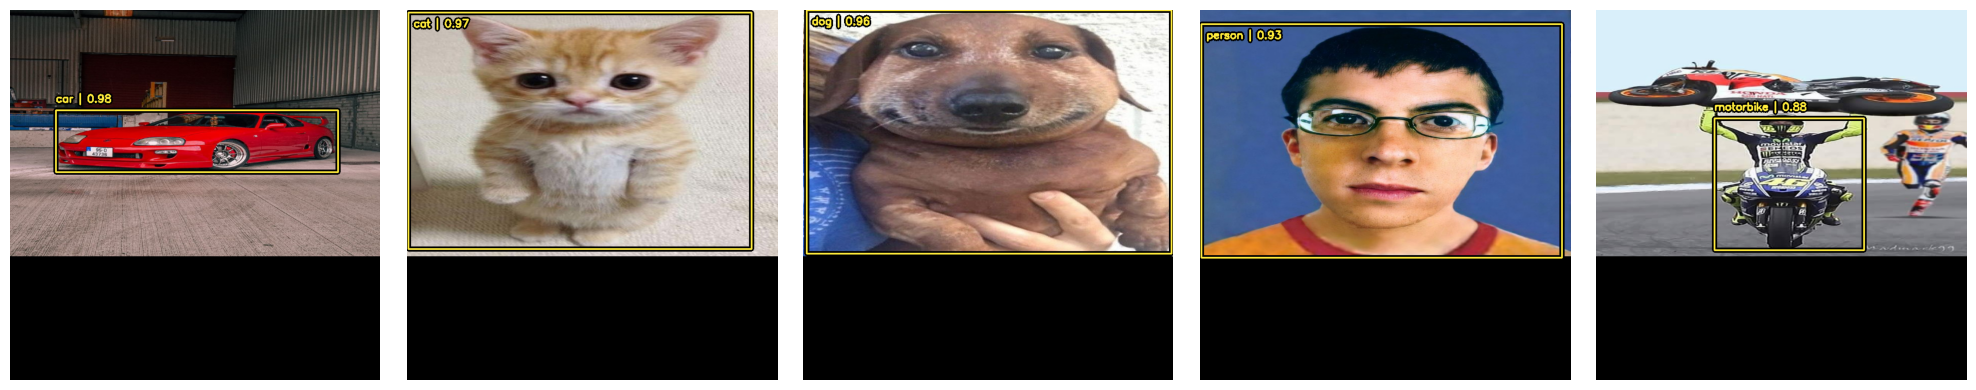

In [1]:
import numpy as np
import tensorflow as tf
import keras_cv
from PIL import Image
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
from io import BytesIO

VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

def download_image(url: str, size=(900, 600)) -> np.ndarray | None:
    """
    Downloads image, converts to RGB, resizes to fixed size for batching.
    Returns None if download fails.
    """
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        req = Request(url, headers=headers)
        data = urlopen(req, timeout=60).read()
        img = Image.open(BytesIO(data)).convert("RGB")
        img = img.resize(size, Image.Resampling.LANCZOS)  
        return np.array(img)
    except (HTTPError, URLError, TimeoutError, OSError) as e:
        print(f"[SKIP] {url}\n       -> {type(e).__name__}: {e}")
        return None


image_urls = [
    "https://i.pinimg.com/736x/4a/04/30/4a0430afa6eb872f74bca978e6c607f1.jpg",
    "https://i.pinimg.com/736x/dc/92/1e/dc921ec2e07f9437dc51f2a10694578d.jpg",  
    "https://i.pinimg.com/736x/6e/41/f4/6e41f405abc35f5695f0c17f34d8229b.jpg",
    "https://i.pinimg.com/736x/6a/d7/9b/6ad79b912b52af3ca4da69fd313d24c5.jpg",
    "https://i.pinimg.com/736x/d6/2b/dc/d62bdcbce14d0d0e268dc72f22be50fc.jpg",
]

images_list = []
good_urls = []

for u in image_urls:
    arr = download_image(u, size=(900, 600))
    if arr is not None:
        images_list.append(arr)
        good_urls.append(u)

if len(images_list) < 1:
    raise RuntimeError("No images downloaded. Replace URLs with valid image links.")

images_np = np.stack(images_list, axis=0)
print("Downloaded:", len(images_list), "images")
print("OK URLs:", *good_urls, sep="\n- ")

resize = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)
images_resized = resize(tf.convert_to_tensor(images_np))

predictions = detector.predict(images_resized, verbose=0)

keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    y_pred=predictions,
    bounding_box_format="xywh",
    class_mapping=dict(enumerate(VOC_CLASS_NAMES)),
    rows=1,
    cols=min(5, len(images_list)),
    scale=4,
    font_scale=0.6,
    show=True,
)